

## Objetivo del Análisis 1
Identificar qué productos son más difíciles de encontrar en las MIPYMES físicas,
basado en el porcentaje de establecimientos que los ofrecen.

📊 30 MIPYMES, 12 productos

📋 Top 5 más difíciles:
• Sal: 26.7%
• Huevos: 33.3%
• Papel Higienico: 33.3%
• Detergente: 43.3%
• Pechuga de pollo: 50.0%


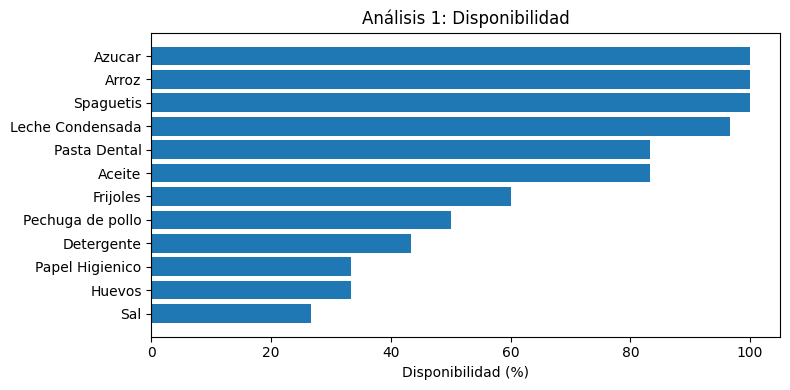

In [3]:

import sys
sys.path.append('../Src')

# 1. Importar funciones
import A1 as fa

# 2. Cargar y analizar
datos = fa.cargar_datos('../Data/procesados/productos_planos.json')
resultados, total = fa.calcular_disponibilidad(datos)

# 3. Mostrar
print(f"📊 {total} MIPYMES, {len(resultados)} productos")
print("\n📋 Top 5 más difíciles:")
for prod, pct, cant in resultados[:5]:
    print(f"• {prod}: {pct:.1f}%")

# 4. Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.barh([r[0] for r in resultados], [r[1] for r in resultados])
plt.xlabel('Disponibilidad (%)')
plt.title('Análisis 1: Disponibilidad')
plt.tight_layout()
plt.show()

NameError: name 'mas_barato' is not defined

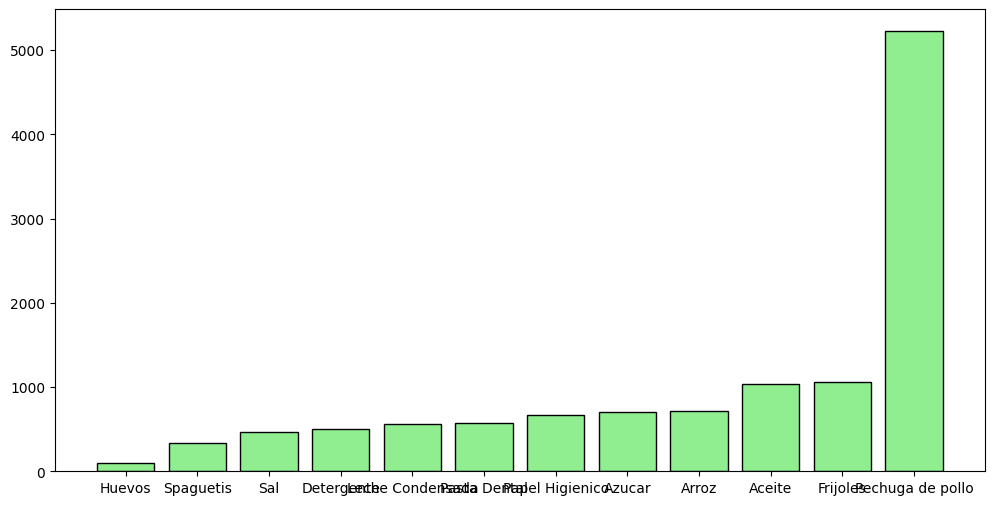

In [7]:
# notebooks/analisis2.ipynb

import sys
sys.path.append('../Src')

# Importar funciones de precios
import A2 as pr
import A1 as an

datos = an.cargar_datos('../Data/procesados/productos_planos.json')
precios = pr.calcular_precios(datos)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Extraer datos
productos = [p['producto'] for p in precios]
promedios = [p['promedio'] for p in precios]

# Crear gráfico de barras
bars = plt.bar(productos, promedios, color='lightgreen', edgecolor='black')

# Destacar el más caro y más barato
if mas_barato and mas_caro:
    idx_barato = productos.index(mas_barato['producto'])
    idx_caro = productos.index(mas_caro['producto'])

    bars[idx_barato].set_color('blue')
    bars[idx_caro].set_color('red')

# Personalizar
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Precio promedio (CUP)', fontsize=12)
plt.title('PRECIOS PROMEDIO POR PRODUCTO\n(Azul: más barato, Rojo: más caro)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for bar, promedio in zip(bars, promedios):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'${promedio:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

# Calcular variaciones
variaciones = pr.calcular_variacion_precios(precios)

# Tomar los 10 con mayor variación
top_variaciones = variaciones[:10]

productos_var = [v['producto'] for v in top_variaciones]
valores_var = [v['variacion'] for v in top_variaciones]

# Gráfico de barras horizontales
plt.barh(productos_var, valores_var, color='orange')

plt.xlabel('Variación de precio (%)\n((Máx - Mín) / Mín * 100)', fontsize=11)
plt.title('PRODUCTOS CON MAYOR VARIACIÓN DE PRECIOS\n(Top 10)',
          fontsize=14, fontweight='bold', pad=20)

# Agregar valores
for i, (prod, var) in enumerate(zip(productos_var, valores_var)):
    plt.text(var + 1, i, f'{var:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Calcular estadísticas generales
todos_precios = []
for registro in datos:
    todos_precios.append(registro['precio_cup'])

precio_promedio_general = sum(todos_precios) / len(todos_precios)



📊 Fuente: Oficina Nacional de Estadística e Información de Cuba (ONEI)
📅 Fecha: Septiembre 2025
📈 Actividades económicas: 18


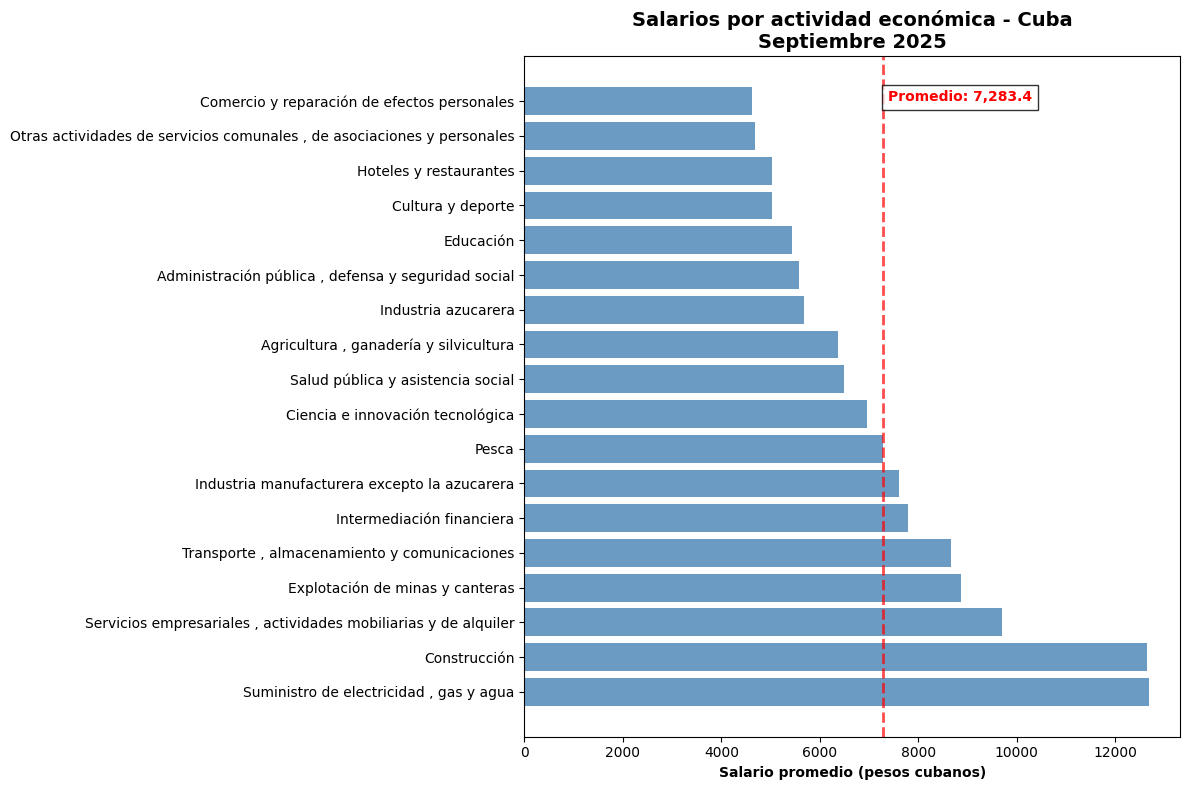

In [6]:
# notebook.ipynb

# Celda 1: Cargar directamente el JSON procesado
import json
import os

# Ruta al archivo procesado (ajusta según tu estructura)
with open('../Data/Crudos/salarios_cuba/salarios_procesados.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

print(f"📊 Fuente: {datos['fuente']}")
print(f"📅 Fecha: {datos['fecha_datos']}")
print(f"📈 Actividades económicas: {len(datos['salarios_ordenados'])}")

# Celda 2: Gráfico simple
import matplotlib.pyplot as plt

actividades = list(datos['salarios_ordenados'].keys())
salarios = list(datos['salarios_ordenados'].values())

plt.figure(figsize=(12, 8))
bars = plt.barh(actividades, salarios, color='steelblue', alpha=0.8)

# Personalizar
plt.xlabel('Salario promedio (pesos cubanos)', fontweight='bold')
plt.title(f'Salarios por actividad económica - Cuba\n{datos["fecha_datos"]}', fontsize=14, fontweight='bold')

# Línea de promedio
promedio = sum(salarios) / len(salarios)
plt.axvline(x=promedio, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.text(promedio + 100, len(actividades)-1, f'Promedio: {promedio:,.1f}',
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()